# Phase 2 — FIFA 2026 World Cup Simulation

Monte Carlo simulation using Phase 2 model (EA squad features + ELO, no Dixon-Coles blend).

**Model:** XGB×3 + RF×1 (log loss 0.8258, 97 features)  
**Scorelines:** Outcome-first sampling → Poisson rejection sampling for matching scoreline  
**Bracket:** FIFA-style R32 — third-place teams face group winners (not each other)  
**Simulations:** 10,000 full tournaments  
**Format:** 48 teams, 12 groups, Round of 32 → Final

**Key changes from Phase 1:**
- EA/FM squad ratings replace DC blend → fixes confederation bias
- Outcome-first simulation → model probabilities directly decide match winner
- FIFA-style R32 bracket → third-place teams get harder draws (face group winners)

In [1]:
import numpy as np
import pandas as pd
import joblib
import warnings
from pathlib import Path
from scipy.stats import poisson
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
PROCESSED_DIR = Path('../../data/processed')
MODELS_DIR    = Path('../../models')

print('Libraries loaded.')

Libraries loaded.


## Step 1: Load Phase 2 Model & Data

In [2]:
# Load Phase 2 model
bundle = joblib.load(MODELS_DIR / 'phase2_model.pkl')
xgb_model = bundle['xgb']
rf_model  = bundle['rf']
W_XGB     = bundle['w_xgb']   # 3
W_RF      = bundle['w_rf']    # 1
le        = bundle['label_encoder']
FEATURE_COLS = bundle['feature_cols']

print(f'Model weights: XGB={W_XGB}, RF={W_RF}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Classes: {le.classes_}')
print(f'Phase: {bundle["phase"]}, Log loss: {bundle["log_loss"]:.4f}')

Model weights: XGB=3, RF=1
Features: 97
Classes: ['away_win' 'draw' 'home_win']
Phase: 2, Log loss: 0.8258


In [3]:
# Load team data
teams_2026 = pd.read_csv(PROCESSED_DIR / 'teams_2026.csv')
schedule   = pd.read_csv(PROCESSED_DIR / 'schedule_2026.csv')
elos       = pd.read_csv(PROCESSED_DIR / 'final_elos.csv').set_index('team')['final_elo'].to_dict()
confs      = pd.read_csv(PROCESSED_DIR / 'team_confederations.csv').set_index('team')['confederation'].to_dict()
fm         = pd.read_csv(PROCESSED_DIR / 'features_matrix.csv', parse_dates=['date']).sort_values('date')
team_features_df = pd.read_csv(PROCESSED_DIR / 'team_features_by_year.csv')

# Form lookups
_home_form_cols = [
    'home_win_rate_5','home_avg_scored_5','home_avg_conceded_5',
    'home_pts_per_match_5','home_matches_played_5',
    'home_win_rate_10','home_avg_scored_10','home_avg_conceded_10',
    'home_pts_per_match_10','home_matches_played_10',
]
_away_form_cols = [
    'away_win_rate_5','away_avg_scored_5','away_avg_conceded_5',
    'away_pts_per_match_5','away_matches_played_5',
    'away_win_rate_10','away_avg_scored_10','away_avg_conceded_10',
    'away_pts_per_match_10','away_matches_played_10',
]
latest_home = fm.groupby('home_team')[_home_form_cols].last()
latest_away = fm.groupby('away_team')[_away_form_cols].last()

# H2H lookup
h2h_cols = ['h2h_home_win_rate','h2h_home_avg_scored','h2h_home_avg_conceded',
            'h2h_total_meetings','h2h_recent_win_rate']
h2h_lookup = fm.groupby(['home_team','away_team'])[h2h_cols].last().to_dict('index')

# Squad features lookup (pre-built dict for speed)
SQUAD_FEATURES = [
    'squad_avg_overall','squad_median_overall','squad_std_overall',
    'squad_top3_avg','squad_bottom5_avg',
    'gk_avg','def_avg','mid_avg','fwd_avg',
    'strongest_unit','weakest_unit',
    'squad_total_value','squad_avg_value',
    'squad_avg_age','squad_avg_potential_gap','squad_avg_caps',
    'team_pace','team_shooting','team_passing',
    'team_dribbling','team_defending','team_physic',
]
tf_avail_years = sorted(team_features_df['year'].unique())
squad_lookup = {}
for _, r in team_features_df.iterrows():
    squad_lookup[(r['team'], int(r['year']))] = {f: r[f] for f in SQUAD_FEATURES}
NAN_SQUAD = {f: np.nan for f in SQUAD_FEATURES}

print(f'Teams: {len(teams_2026)}, Schedule: {len(schedule)} matches')
print(f'Squad features: {len(squad_lookup)} team-year entries')
print(f'H2H pairs: {len(h2h_lookup)}')

Teams: 48, Schedule: 72 matches
Squad features: 2831 team-year entries
H2H pairs: 13031


## Step 2: Feature Builder & Predictor

In [4]:
ALL_CONFS = ['UEFA','CAF','AFC','CONCACAF','CONMEBOL','OFC','UNKNOWN']

def conf_onehot(team):
    conf = confs.get(team, 'UNKNOWN')
    return {f'conf_{c}': int(conf == c) for c in ALL_CONFS}

def get_form(team):
    if team in latest_home.index:
        row = latest_home.loc[team]
        return {
            'win_rate_5': row.get('home_win_rate_5', 0.5),
            'avg_scored_5': row.get('home_avg_scored_5', 1.3),
            'avg_conceded_5': row.get('home_avg_conceded_5', 1.0),
            'pts_per_match_5': row.get('home_pts_per_match_5', 1.5),
            'matches_played_5': row.get('home_matches_played_5', 5),
            'win_rate_10': row.get('home_win_rate_10', 0.5),
            'avg_scored_10': row.get('home_avg_scored_10', 1.3),
            'avg_conceded_10': row.get('home_avg_conceded_10', 1.0),
            'pts_per_match_10': row.get('home_pts_per_match_10', 1.5),
            'matches_played_10': row.get('home_matches_played_10', 10),
        }
    if team in latest_away.index:
        row = latest_away.loc[team]
        return {
            'win_rate_5': row.get('away_win_rate_5', 0.5),
            'avg_scored_5': row.get('away_avg_scored_5', 1.0),
            'avg_conceded_5': row.get('away_avg_conceded_5', 1.3),
            'pts_per_match_5': row.get('away_pts_per_match_5', 1.2),
            'matches_played_5': row.get('away_matches_played_5', 5),
            'win_rate_10': row.get('away_win_rate_10', 0.5),
            'avg_scored_10': row.get('away_avg_scored_10', 1.0),
            'avg_conceded_10': row.get('away_avg_conceded_10', 1.3),
            'pts_per_match_10': row.get('away_pts_per_match_10', 1.2),
            'matches_played_10': row.get('away_matches_played_10', 10),
        }
    return {'win_rate_5':0.5,'avg_scored_5':1.3,'avg_conceded_5':1.3,
            'pts_per_match_5':1.5,'matches_played_5':5,
            'win_rate_10':0.5,'avg_scored_10':1.3,'avg_conceded_10':1.3,
            'pts_per_match_10':1.5,'matches_played_10':10}

def get_h2h(home, away):
    if (home, away) in h2h_lookup:
        d = h2h_lookup[(home, away)]
        return d['h2h_home_win_rate'], d['h2h_home_avg_scored'], \
               d['h2h_home_avg_conceded'], d['h2h_total_meetings'], d['h2h_recent_win_rate']
    return 0.5, 1.3, 1.3, 0, 0.5

def get_squad(team, year=2026):
    candidates = [y for y in tf_avail_years if y <= year]
    if not candidates:
        return NAN_SQUAD
    return squad_lookup.get((team, max(candidates)), NAN_SQUAD)

print('Helper functions defined.')

Helper functions defined.


In [5]:
def build_features(home, away, neutral=True):
    """Build 97-feature vector for Phase 2 model."""
    home_elo = elos.get(home, 1500)
    away_elo = elos.get(away, 1500)
    elo_diff = home_elo - away_elo

    hf = get_form(home)
    af = get_form(away)
    h2h_hw, h2h_hs, h2h_hc, h2h_tm, h2h_rw = get_h2h(home, away)

    hc = conf_onehot(home)
    ac = conf_onehot(away)
    same_conf = int(confs.get(home, 'X') == confs.get(away, 'Y'))

    home_form_momentum = hf['win_rate_5'] - hf['win_rate_10']
    away_form_momentum = af['win_rate_5'] - af['win_rate_10']
    home_gdf = hf['avg_scored_5'] - hf['avg_conceded_5']
    away_gdf = af['avg_scored_5'] - af['avg_conceded_5']
    net_goal_diff = home_gdf - away_gdf
    h2h_confidence = h2h_rw * (h2h_tm / (h2h_tm + 5))

    hsq = get_squad(home)
    asq = get_squad(away)

    # 22 diffs
    sq_diffs = {f'{f}_diff': hsq[f] - asq[f] for f in SQUAD_FEATURES}

    # Engineered EA features
    h_ov = hsq['squad_avg_overall']; a_ov = asq['squad_avg_overall']
    h_t3 = hsq['squad_top3_avg']; a_t3 = asq['squad_top3_avg']
    h_val = hsq['squad_total_value']; a_val = asq['squad_total_value']

    def safe(a, b, op='sub'):
        if np.isnan(a) or np.isnan(b): return np.nan
        if op == 'sub': return a - b
        if op == 'div': return a / max(b, 1)
        if op == 'logdiff': return np.log1p(a) - np.log1p(b)
        if op == 'ratio': return (a + 1) / (b + 1)

    overall_ratio = safe(h_ov, a_ov, 'div')
    top3_ratio = safe(h_t3, a_t3, 'div')
    value_ratio_log = safe(h_val, a_val, 'logdiff')
    value_ratio = safe(h_val, a_val, 'ratio')

    h_bal = safe(hsq['strongest_unit'], hsq['weakest_unit'])
    a_bal = safe(asq['strongest_unit'], asq['weakest_unit'])
    squad_balance_diff = safe(h_bal, a_bal)

    h_sg = safe(h_t3, h_ov); a_sg = safe(a_t3, a_ov)
    star_gap_diff = safe(h_sg, a_sg)

    h_avd = safe(hsq['fwd_avg'], asq['def_avg'])
    a_avd = safe(asq['fwd_avg'], hsq['def_avg'])

    h_ws = (0.6 * h_ov + 0.4 * h_t3) if not (np.isnan(h_ov) or np.isnan(h_t3)) else np.nan
    a_ws = (0.6 * a_ov + 0.4 * a_t3) if not (np.isnan(a_ov) or np.isnan(a_t3)) else np.nan

    feat = {
        'home_win_rate_5': hf['win_rate_5'], 'home_avg_scored_5': hf['avg_scored_5'],
        'home_avg_conceded_5': hf['avg_conceded_5'], 'home_pts_per_match_5': hf['pts_per_match_5'],
        'home_matches_played_5': hf['matches_played_5'],
        'home_win_rate_10': hf['win_rate_10'], 'home_avg_scored_10': hf['avg_scored_10'],
        'home_avg_conceded_10': hf['avg_conceded_10'], 'home_pts_per_match_10': hf['pts_per_match_10'],
        'home_matches_played_10': hf['matches_played_10'],
        'away_win_rate_5': af['win_rate_5'], 'away_avg_scored_5': af['avg_scored_5'],
        'away_avg_conceded_5': af['avg_conceded_5'], 'away_pts_per_match_5': af['pts_per_match_5'],
        'away_matches_played_5': af['matches_played_5'],
        'away_win_rate_10': af['win_rate_10'], 'away_avg_scored_10': af['avg_scored_10'],
        'away_avg_conceded_10': af['avg_conceded_10'], 'away_pts_per_match_10': af['pts_per_match_10'],
        'away_matches_played_10': af['matches_played_10'],
        'home_form_momentum': home_form_momentum, 'away_form_momentum': away_form_momentum,
        'home_goal_diff_form': home_gdf, 'away_goal_diff_form': away_gdf,
        'net_goal_diff': net_goal_diff,
        'h2h_home_win_rate': h2h_hw, 'h2h_home_avg_scored': h2h_hs,
        'h2h_home_avg_conceded': h2h_hc, 'h2h_total_meetings': h2h_tm,
        'h2h_recent_win_rate': h2h_rw, 'h2h_confidence': h2h_confidence,
        'neutral.1': int(neutral), 'tournament_importance': 60,
        'home_conf_UEFA': hc['conf_UEFA'], 'home_conf_CAF': hc['conf_CAF'],
        'home_conf_AFC': hc['conf_AFC'], 'home_conf_CONCACAF': hc['conf_CONCACAF'],
        'home_conf_CONMEBOL': hc['conf_CONMEBOL'], 'home_conf_OFC': hc['conf_OFC'],
        'home_conf_UNKNOWN': hc['conf_UNKNOWN'],
        'away_conf_UEFA': ac['conf_UEFA'], 'away_conf_CAF': ac['conf_CAF'],
        'away_conf_AFC': ac['conf_AFC'], 'away_conf_CONCACAF': ac['conf_CONCACAF'],
        'away_conf_CONMEBOL': ac['conf_CONMEBOL'], 'away_conf_OFC': ac['conf_OFC'],
        'away_conf_UNKNOWN': ac['conf_UNKNOWN'],
        'same_confederation': same_conf,
        **sq_diffs,
        'overall_ratio': overall_ratio, 'top3_ratio': top3_ratio,
        'value_ratio_log': value_ratio_log, 'value_ratio': value_ratio,
        'squad_balance_diff': squad_balance_diff, 'star_gap_diff': star_gap_diff,
        'depth_diff': sq_diffs.get('squad_bottom5_avg_diff', np.nan),
        'squad_std_diff': sq_diffs.get('squad_std_overall_diff', np.nan),
        'home_attack_vs_def': h_avd, 'away_attack_vs_def': a_avd,
        'attack_vs_def_diff': safe(h_avd, a_avd),
        'mid_battle': sq_diffs.get('mid_avg_diff', np.nan),
        'gk_diff': sq_diffs.get('gk_avg_diff', np.nan),
        'pace_diff': sq_diffs.get('team_pace_diff', np.nan),
        'physic_diff': sq_diffs.get('team_physic_diff', np.nan),
        'shooting_diff': sq_diffs.get('team_shooting_diff', np.nan),
        'passing_diff': sq_diffs.get('team_passing_diff', np.nan),
        'defending_diff': sq_diffs.get('team_defending_diff', np.nan),
        'dribbling_diff': sq_diffs.get('team_dribbling_diff', np.nan),
        'age_diff': sq_diffs.get('squad_avg_age_diff', np.nan),
        'caps_diff': sq_diffs.get('squad_avg_caps_diff', np.nan),
        'potential_gap_diff': sq_diffs.get('squad_avg_potential_gap_diff', np.nan),
        'weighted_strength_diff': safe(h_ws, a_ws),
        'elo_diff': elo_diff, 'elo_diff_sq': elo_diff**2 * np.sign(elo_diff),
        'home_elo_before': home_elo, 'away_elo_before': away_elo,
    }

    return np.array([feat.get(c, np.nan) for c in FEATURE_COLS], dtype=float)

# Test
feat = build_features('Spain', 'Brazil', neutral=True)
print(f'Feature vector: {len(feat)} (expected {len(FEATURE_COLS)})')

Feature vector: 97 (expected 97)


## Step 3: Batch Predict + Reverse Poisson Cache

In [6]:
%%time
# Build Poisson lookup grid (one-time)
GRID_STEP = 0.1
GRID_MAX = 4.0
MAX_G = 8
grid_vals = np.arange(0.1, GRID_MAX + GRID_STEP, GRID_STEP)
grid_n = len(grid_vals)
goals = np.arange(MAX_G + 1)

pmf_cache = np.array([poisson.pmf(goals, lam) for lam in grid_vals])
all_mats = np.einsum('ig,jh->ijgh', pmf_cache, pmf_cache)

g = MAX_G + 1
home_mask = np.tril(np.ones((g, g), dtype=bool), -1)
draw_mask = np.eye(g, dtype=bool)
away_mask = np.triu(np.ones((g, g), dtype=bool), 1)

grid_ph = np.sum(all_mats * home_mask, axis=(2, 3))
grid_pdr = np.sum(all_mats * draw_mask, axis=(2, 3))  # pdr not pd — avoid shadowing pandas
grid_pa = np.sum(all_mats * away_mask, axis=(2, 3))
del all_mats

def fit_poisson_lambdas(p_home, p_draw, p_away):
    err = (grid_ph - p_home)**2 + (grid_pdr - p_draw)**2 + (grid_pa - p_away)**2
    idx = np.unravel_index(np.argmin(err), err.shape)
    return float(grid_vals[idx[0]]), float(grid_vals[idx[1]])

print(f'Poisson grid: {grid_n}x{grid_n} = {grid_n**2} entries')
# Verify
lh, la = fit_poisson_lambdas(0.6, 0.25, 0.15)
print(f'Test: p=(0.6, 0.25, 0.15) -> lam=({lh:.1f}, {la:.1f})')

Poisson grid: 40x40 = 1600 entries
Test: p=(0.6, 0.25, 0.15) -> lam=(1.5, 0.6)
CPU times: total: 15.6 ms
Wall time: 15.3 ms


In [7]:
%%time
# Batch predict all 48x47 = 2,256 matchups at once
all_wc_teams = teams_2026['team'].tolist()

pairs = []
feat_rows = []
for home in all_wc_teams:
    for away in all_wc_teams:
        if home != away:
            pairs.append((home, away))
            feat_rows.append(build_features(home, away, neutral=True))

X = np.array(feat_rows)
X_rf = np.nan_to_num(X, 0)

# Batch inference — much faster than one-at-a-time
xgb_probs = xgb_model.predict_proba(X)
rf_probs  = rf_model.predict_proba(X_rf)
blended   = (W_XGB * xgb_probs + W_RF * rf_probs) / (W_XGB + W_RF)

# Build caches
prob_cache = {}    # (home, away) -> (p_home, p_draw, p_away)
lambda_cache = {}  # (home, away) -> (lam_h, lam_a)

for i, (home, away) in enumerate(pairs):
    p_away = float(blended[i, 0])  # le.classes_ = [away_win, draw, home_win]
    p_draw = float(blended[i, 1])
    p_home = float(blended[i, 2])
    prob_cache[(home, away)] = (p_home, p_draw, p_away)
    lambda_cache[(home, away)] = fit_poisson_lambdas(p_home, p_draw, p_away)

print(f'Cached {len(prob_cache)} matchups.')

# Sanity checks
print('\nSanity checks (neutral):')
for h, a in [('Spain','Qatar'),('Argentina','France'),('Brazil','Mexico'),
             ('England','Germany'),('France','Brazil')]:
    p_h, p_d, p_a = prob_cache[(h, a)]
    lh, la = lambda_cache[(h, a)]
    print(f'  {h:12s} vs {a:12s}  H={p_h:.3f} D={p_d:.3f} A={p_a:.3f}  lam=({lh:.1f},{la:.1f})')

Cached 2256 matchups.

Sanity checks (neutral):
  Spain        vs Qatar         H=0.856 D=0.109 A=0.035  lam=(2.7,0.4)
  Argentina    vs France        H=0.394 D=0.294 A=0.313  lam=(1.2,1.0)
  Brazil       vs Mexico        H=0.611 D=0.258 A=0.131  lam=(1.5,0.5)
  England      vs Germany       H=0.571 D=0.252 A=0.177  lam=(1.5,0.7)
  France       vs Brazil        H=0.635 D=0.246 A=0.119  lam=(1.6,0.5)
CPU times: total: 2.5 s
Wall time: 1.4 s


## Step 4: Group Stage & Knockout Simulators

In [8]:
def _sample_scoreline(lam_h, lam_a, outcome):
    """Rejection-sample a Poisson scoreline consistent with the chosen outcome."""
    for _ in range(100):
        hg = int(np.random.poisson(lam_h))
        ag = int(np.random.poisson(lam_a))
        if outcome == 'home' and hg > ag: return hg, ag
        if outcome == 'away' and ag > hg: return hg, ag
        if outcome == 'draw' and hg == ag: return hg, ag
    # Fallback
    if outcome == 'home':   return max(1, int(np.random.poisson(lam_h))), 0
    elif outcome == 'away': return 0, max(1, int(np.random.poisson(lam_a)))
    else:
        g = int(np.random.poisson(min(lam_h, lam_a)))
        return g, g

def simulate_match_group(home, away):
    """Outcome-first: model probs decide winner, then rejection-sample scoreline."""
    ph, pd_, pa = prob_cache[(home, away)]
    lam_h, lam_a = lambda_cache[(home, away)]

    outcome = np.random.choice(['home', 'draw', 'away'], p=[ph, pd_, pa])
    home_goals, away_goals = _sample_scoreline(lam_h, lam_a, outcome)

    if outcome == 'home':   h_pts, a_pts = 3, 0
    elif outcome == 'away': h_pts, a_pts = 0, 3
    else:                   h_pts, a_pts = 1, 1

    return h_pts, a_pts, home_goals - away_goals, away_goals - home_goals, home_goals, away_goals

def simulate_group(group_teams, group_matches):
    stats = {t: {'pts':0, 'gd':0, 'gf':0, 'team':t} for t in group_teams}
    for _, row in group_matches.iterrows():
        h, a = row['home_team'], row['away_team']
        h_pts, a_pts, h_gd, a_gd, hg, ag = simulate_match_group(h, a)
        stats[h]['pts'] += h_pts; stats[a]['pts'] += a_pts
        stats[h]['gd'] += h_gd;   stats[a]['gd'] += a_gd
        stats[h]['gf'] += hg;     stats[a]['gf'] += ag
    return sorted(stats.values(), key=lambda x: (x['pts'], x['gd'], x['gf']), reverse=True)

def simulate_all_groups():
    winners, runners_up, third_place = {}, {}, []
    for group in sorted(teams_2026['group'].unique()):
        group_teams = teams_2026[teams_2026['group'] == group]['team'].tolist()
        group_matches = schedule[schedule['group'] == group]
        standing = simulate_group(group_teams, group_matches)
        winners[group] = standing[0]['team']
        runners_up[group] = standing[1]['team']
        third_place.append({
            'team': standing[2]['team'], 'pts': standing[2]['pts'],
            'gd': standing[2]['gd'], 'gf': standing[2]['gf'], 'group': group,
        })
    third_sorted = sorted(third_place, key=lambda x: (x['pts'], x['gd'], x['gf']), reverse=True)
    best_thirds = {d['group']: d['team'] for d in third_sorted[:8]}
    return winners, runners_up, best_thirds, third_sorted

# ── Official FIFA 2026 third-place allocation table (495 combinations) ──
# Source: FIFA Regulations Annex C / Wikipedia 2026 FIFA World Cup knockout stage
import json as _json
with open(str(Path('../../third_place_allocation.json'))) as _f:
    THIRD_PLACE_TABLE = _json.load(_f)

# Pre-index by frozenset for O(1) lookup
_THIRD_ALLOC_INDEX = {
    frozenset(entry['qualifying_groups']): entry['assignments']
    for entry in THIRD_PLACE_TABLE
}

def _lookup_third_allocation(qualifying_groups):
    """Look up which third-place team goes to which match, per FIFA Annex C."""
    key = frozenset(qualifying_groups)
    if key in _THIRD_ALLOC_INDEX:
        return _THIRD_ALLOC_INDEX[key]
    raise ValueError(f"No allocation found for qualifying groups: {sorted(qualifying_groups)}")

def build_r32_bracket(winners, runners_up, best_thirds):
    """
    Official FIFA 2026 R32 bracket (Matches 73-88).
    Source: FIFA match schedule + Annex C third-place allocation.
    
    Fixed matches (no third-place dependency):
      M73: 2A vs 2B    M75: 1F vs 2C    M76: 1C vs 2F    M78: 2E vs 2I
      M83: 2K vs 2L    M84: 1H vs 2J    M86: 1J vs 2H    M88: 2D vs 2G
    
    Third-place matches (allocation from Annex C based on which 8 groups qualify):
      M74: 1E vs 3rd    M77: 1I vs 3rd    M79: 1A vs 3rd    M80: 1L vs 3rd
      M81: 1D vs 3rd    M82: 1G vs 3rd    M85: 1B vs 3rd    M87: 1K vs 3rd
    """
    alloc = _lookup_third_allocation(list(best_thirds.keys()))
    
    r32 = {}
    # Fixed matches
    r32[73] = (runners_up['A'], runners_up['B'])
    r32[75] = (winners['F'], runners_up['C'])
    r32[76] = (winners['C'], runners_up['F'])
    r32[78] = (runners_up['E'], runners_up['I'])
    r32[83] = (runners_up['K'], runners_up['L'])
    r32[84] = (winners['H'], runners_up['J'])
    r32[86] = (winners['J'], runners_up['H'])
    r32[88] = (runners_up['D'], runners_up['G'])
    
    # Third-place matches
    r32[74] = (winners['E'], best_thirds[alloc['74']])
    r32[77] = (winners['I'], best_thirds[alloc['77']])
    r32[79] = (winners['A'], best_thirds[alloc['79']])
    r32[80] = (winners['L'], best_thirds[alloc['80']])
    r32[81] = (winners['D'], best_thirds[alloc['81']])
    r32[82] = (winners['G'], best_thirds[alloc['82']])
    r32[85] = (winners['B'], best_thirds[alloc['85']])
    r32[87] = (winners['K'], best_thirds[alloc['87']])
    
    return r32

# Official FIFA knockout bracket path (R16 through Final)
R16_PAIRINGS = [(74, 77), (73, 75), (76, 78), (79, 80), (83, 84), (81, 82), (86, 88), (85, 87)]
QF_PAIRINGS  = [(0, 1), (4, 5), (2, 3), (6, 7)]  # indices into R16 winners
SF_PAIRINGS  = [(0, 1), (2, 3)]                     # indices into QF winners

def simulate_ko_match(t1, t2):
    """Outcome-first knockout: model probs decide, draw → penalties."""
    ph, pd_, pa = prob_cache[(t1, t2)]
    lam_h, lam_a = lambda_cache[(t1, t2)]

    outcome = np.random.choice(['home', 'draw', 'away'], p=[ph, pd_, pa])
    t1_goals, t2_goals = _sample_scoreline(lam_h, lam_a, outcome)

    if outcome == 'home':
        return t1
    elif outcome == 'away':
        return t2
    else:
        return t1 if np.random.random() < ph / (ph + pa) else t2

print(f'Simulators defined (outcome-first + official FIFA 2026 bracket).')
print(f'Third-place allocation table: {len(THIRD_PLACE_TABLE)} combinations loaded.')

Simulators defined (outcome-first + official FIFA 2026 bracket).
Third-place allocation table: 495 combinations loaded.


In [9]:
def simulate_tournament():
    winners, runners_up, best_thirds, _ = simulate_all_groups()

    _g2026 = teams_2026.groupby('group')['team'].apply(list).to_dict()
    all_48 = [t for grp in _g2026.values() for t in grp]
    round_reached = {t: 'Group' for t in all_48}

    r32_qualified = list(winners.values()) + list(runners_up.values()) + list(best_thirds.values())
    for t in r32_qualified:
        round_reached[t] = 'R32'

    # ── R32: play matches 73-88, store winners by match number ──
    r32 = build_r32_bracket(winners, runners_up, best_thirds)
    r32_winners = {}
    for match_num, (t1, t2) in r32.items():
        r32_winners[match_num] = simulate_ko_match(t1, t2)

    # ── R16: official FIFA pairings (winner of M74 vs winner of M77, etc.) ──
    r16_winners = []
    for m_a, m_b in R16_PAIRINGS:
        t1, t2 = r32_winners[m_a], r32_winners[m_b]
        round_reached[t1] = 'R16'
        round_reached[t2] = 'R16'
        r16_winners.append(simulate_ko_match(t1, t2))

    # ── QF: indices into r16_winners ──
    qf_winners = []
    for i_a, i_b in QF_PAIRINGS:
        t1, t2 = r16_winners[i_a], r16_winners[i_b]
        round_reached[t1] = 'QF'
        round_reached[t2] = 'QF'
        qf_winners.append(simulate_ko_match(t1, t2))

    # ── SF ──
    sf_winners = []
    for i_a, i_b in SF_PAIRINGS:
        t1, t2 = qf_winners[i_a], qf_winners[i_b]
        round_reached[t1] = 'SF'
        round_reached[t2] = 'SF'
        sf_winners.append(simulate_ko_match(t1, t2))

    # ── Final ──
    t1, t2 = sf_winners[0], sf_winners[1]
    round_reached[t1] = 'Final'
    round_reached[t2] = 'Final'
    champion = simulate_ko_match(t1, t2)
    round_reached[champion] = 'Champion'

    return champion, round_reached

# Quick test
champ, rr = simulate_tournament()
print(f'Test run champion: {champ}')
# Verify round counts
from collections import Counter
rc = Counter(rr.values())
print(f'Round distribution: {dict(rc)}')
assert rc['Group'] == 16, f"Expected 16 out in groups, got {rc['Group']}"
assert rc.get('Champion', 0) == 1, "Expected exactly 1 champion"
print('✓ Bracket structure validated')

Test run champion: Spain
Round distribution: {'QF': 4, 'R32': 16, 'Group': 16, 'R16': 8, 'SF': 2, 'Champion': 1, 'Final': 1}
✓ Bracket structure validated


## Step 5: Monte Carlo — 10,000 Simulations

In [10]:
%%time
N_SIMS = 10_000
champion_counts = {}
round_counts = {}

for _ in tqdm(range(N_SIMS), desc='Simulating'):
    champ, round_reached = simulate_tournament()
    champion_counts[champ] = champion_counts.get(champ, 0) + 1
    for team, rnd in round_reached.items():
        if team not in round_counts:
            round_counts[team] = {}
        round_counts[team][rnd] = round_counts[team].get(rnd, 0) + 1

win_probs = pd.DataFrame([
    {'team': t, 'wins': c, 'win_pct': round(c / N_SIMS * 100, 2)}
    for t, c in champion_counts.items()
]).sort_values('win_pct', ascending=False).reset_index(drop=True)

print(f'\nSimulated {N_SIMS:,} tournaments')
print(f'Teams that won at least once: {len(win_probs)}')
print()
print('=== Phase 2: World Cup Winner Probabilities ===')
print(win_probs.head(20).to_string(index=False))

Simulating:   0%|          | 0/10000 [00:00<?, ?it/s]


Simulated 10,000 tournaments
Teams that won at least once: 39

=== Phase 2: World Cup Winner Probabilities ===
       team  wins  win_pct
      Spain  2140    21.40
     France  2103    21.03
  Argentina  1083    10.83
    England   972     9.72
    Germany   950     9.50
     Brazil   679     6.79
Netherlands   488     4.88
   Portugal   242     2.42
     Norway   226     2.26
   Colombia   188     1.88
    Ecuador   124     1.24
     Turkey    94     0.94
    Uruguay    94     0.94
    Croatia    94     0.94
Switzerland    90     0.90
      Japan    73     0.73
    Belgium    64     0.64
     Mexico    60     0.60
    Morocco    49     0.49
    Senegal    34     0.34
CPU times: total: 2min 11s
Wall time: 2min 13s


In [11]:
# Round reached analysis
ROUND_ORDER = ['Group', 'R32', 'R16', 'QF', 'SF', 'Final', 'Champion']
elo_map = elos

rows = []
for _, trow in teams_2026.iterrows():
    team = trow['team']
    rc = round_counts.get(team, {'Group': N_SIMS})
    row = {'team': team, 'group': trow['group'],
           'confederation': confs.get(team, '?'),
           'elo': round(elo_map.get(team, 0), 0)}
    for r in ROUND_ORDER:
        row[r] = round(rc.get(r, 0) / N_SIMS * 100, 1)
    row['win_pct'] = round(champion_counts.get(team, 0) / N_SIMS * 100, 2)
    rows.append(row)

round_df = pd.DataFrame(rows).sort_values('win_pct', ascending=False).reset_index(drop=True)

print('=== Round Reached Analysis (% of 10,000 simulations) ===')
print()
print(f'{"Team":<22} {"ELO":>5} {"Conf":>9} {"Out GS":>7} {"R32":>6} {"R16":>6} {"QF":>6} {"SF":>6} {"Final":>6} {"Win":>6}')
print('-' * 90)
for _, r in round_df.head(30).iterrows():
    print(f"{r['team']:<22} {r['elo']:>5.0f} {r['confederation']:>9} "
          f"{r['Group']:>6.1f}% {r['R32']:>5.1f}% {r['R16']:>5.1f}% "
          f"{r['QF']:>5.1f}% {r['SF']:>5.1f}% {r['Final']:>5.1f}% {r['win_pct']:>5.2f}%")

=== Round Reached Analysis (% of 10,000 simulations) ===

Team                     ELO      Conf  Out GS    R32    R16     QF     SF  Final    Win
------------------------------------------------------------------------------------------
Spain                   2270      UEFA    1.2%  19.9%  23.4%   5.9%  20.8%   7.5% 21.40%
France                  2211      UEFA    3.6%  17.0%  28.8%   8.6%  11.7%   9.3% 21.03%
Argentina               2227  CONMEBOL    1.9%  27.2%   9.0%  10.2%  26.3%  14.6% 10.83%
England                 2149      UEFA    3.5%  17.5%  24.7%  23.2%  11.1%  10.4%  9.72%
Germany                 2034      UEFA    2.8%  20.6%  33.0%  13.1%  12.5%   8.5%  9.50%
Brazil                  2086  CONMEBOL    2.2%  25.0%  24.2%  18.2%  12.6%  10.9%  6.79%
Netherlands             2044      UEFA    4.0%  29.8%  22.4%  26.3%   6.8%   5.7%  4.88%
Portugal                2054      UEFA    5.3%  25.6%  29.9%  21.2%  11.8%   3.9%  2.42%
Norway                  2023      UEFA   13.3%  37

## Step 6: Phase 1 vs Phase 2 Comparison

In [12]:
# Load Phase 1 results
phase1 = pd.read_csv(PROCESSED_DIR / 'wc2026_simulation_results.csv')
phase1 = phase1[['team', 'win_pct']].rename(columns={'win_pct': 'phase1_pct'})

# Phase 2 results
phase2 = win_probs[['team', 'win_pct']].rename(columns={'win_pct': 'phase2_pct'})

# Merge
comparison = phase1.merge(phase2, on='team', how='outer').fillna(0)
comparison['delta'] = comparison['phase2_pct'] - comparison['phase1_pct']
comparison['confederation'] = comparison['team'].map(confs)
comparison = comparison.sort_values('phase2_pct', ascending=False)

print('Phase 1 vs Phase 2 — Top 20 + biggest movers')
print('='*75)
print(f'{"Team":<22} {"Conf":>9} {"Phase1":>8} {"Phase2":>8} {"Delta":>8}')
print('-'*60)
for _, r in comparison.head(20).iterrows():
    arrow = '↑' if r['delta'] > 1 else ('↓' if r['delta'] < -1 else '=')
    print(f"{r['team']:<22} {r['confederation']:>9} {r['phase1_pct']:>7.2f}% {r['phase2_pct']:>7.2f}% {r['delta']:>+7.2f}% {arrow}")

print('\nBiggest risers (Phase 2 fixed confederation bias):')
for _, r in comparison.nlargest(5, 'delta').iterrows():
    print(f"  {r['team']:<20} {r['confederation']:>9}  {r['phase1_pct']:>6.2f}% → {r['phase2_pct']:>6.2f}%  ({r['delta']:>+.2f}%)")

print('\nBiggest fallers (were inflated by confederation bias):')
for _, r in comparison.nsmallest(5, 'delta').iterrows():
    print(f"  {r['team']:<20} {r['confederation']:>9}  {r['phase1_pct']:>6.2f}% → {r['phase2_pct']:>6.2f}%  ({r['delta']:>+.2f}%)")

Phase 1 vs Phase 2 — Top 20 + biggest movers
Team                        Conf   Phase1   Phase2    Delta
------------------------------------------------------------
Spain                       UEFA   19.52%   21.40%   +1.88% ↑
France                      UEFA   11.68%   21.03%   +9.35% ↑
Argentina               CONMEBOL    7.50%   10.83%   +3.33% ↑
England                     UEFA    7.91%    9.72%   +1.81% ↑
Germany                     UEFA    6.93%    9.50%   +2.57% ↑
Brazil                  CONMEBOL    6.67%    6.79%   +0.12% =
Netherlands                 UEFA    3.45%    4.88%   +1.43% ↑
Portugal                    UEFA    1.21%    2.42%   +1.21% ↑
Norway                      UEFA    4.60%    2.26%   -2.34% ↓
Colombia                CONMEBOL    1.37%    1.88%   +0.51% =
Ecuador                 CONMEBOL    0.84%    1.24%   +0.40% =
Croatia                     UEFA    0.91%    0.94%   +0.03% =
Turkey                      UEFA    1.19%    0.94%   -0.25% =
Uruguay                 CONM

## Step 7: Visualizations

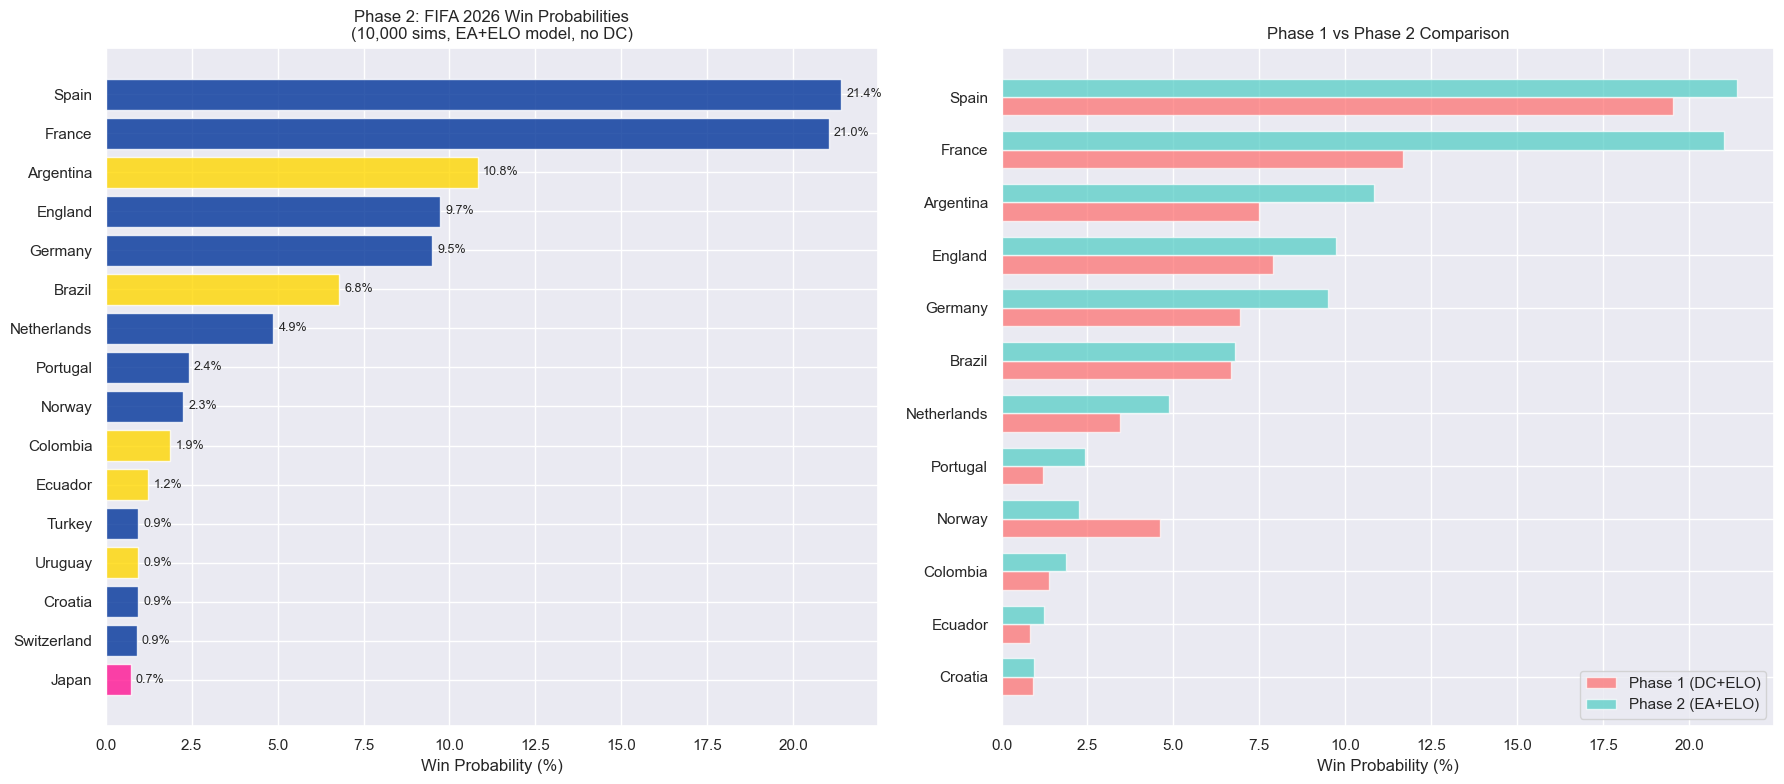

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left: Top 16 win probabilities ---
ax = axes[0]
top16 = win_probs.head(16)
colors = [{'UEFA':'#003399','CONMEBOL':'#FFD700','CONCACAF':'#FF6B35',
           'CAF':'#228B22','AFC':'#FF1493','OFC':'#00CED1'}.get(confs.get(t,''), '#999')
          for t in top16['team']]
bars = ax.barh(top16['team'][::-1], top16['win_pct'][::-1],
               color=colors[::-1], alpha=0.8)
ax.set_xlabel('Win Probability (%)')
ax.set_title('Phase 2: FIFA 2026 Win Probabilities\n(10,000 sims, EA+ELO model, no DC)', fontsize=12)
for bar, val in zip(bars, top16['win_pct'][::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

# --- Right: Phase 1 vs Phase 2 side-by-side ---
ax2 = axes[1]
top12 = comparison.head(12)
y = np.arange(len(top12))
h = 0.35
ax2.barh(y + h/2, top12['phase1_pct'], h, label='Phase 1 (DC+ELO)', color='#FF6B6B', alpha=0.7)
ax2.barh(y - h/2, top12['phase2_pct'], h, label='Phase 2 (EA+ELO)', color='#4ECDC4', alpha=0.7)
ax2.set_yticks(y)
ax2.set_yticklabels(top12['team'])
ax2.set_xlabel('Win Probability (%)')
ax2.set_title('Phase 1 vs Phase 2 Comparison', fontsize=12)
ax2.legend(loc='lower right')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/phase2_04_win_probs.png', dpi=150, bbox_inches='tight')
plt.show()

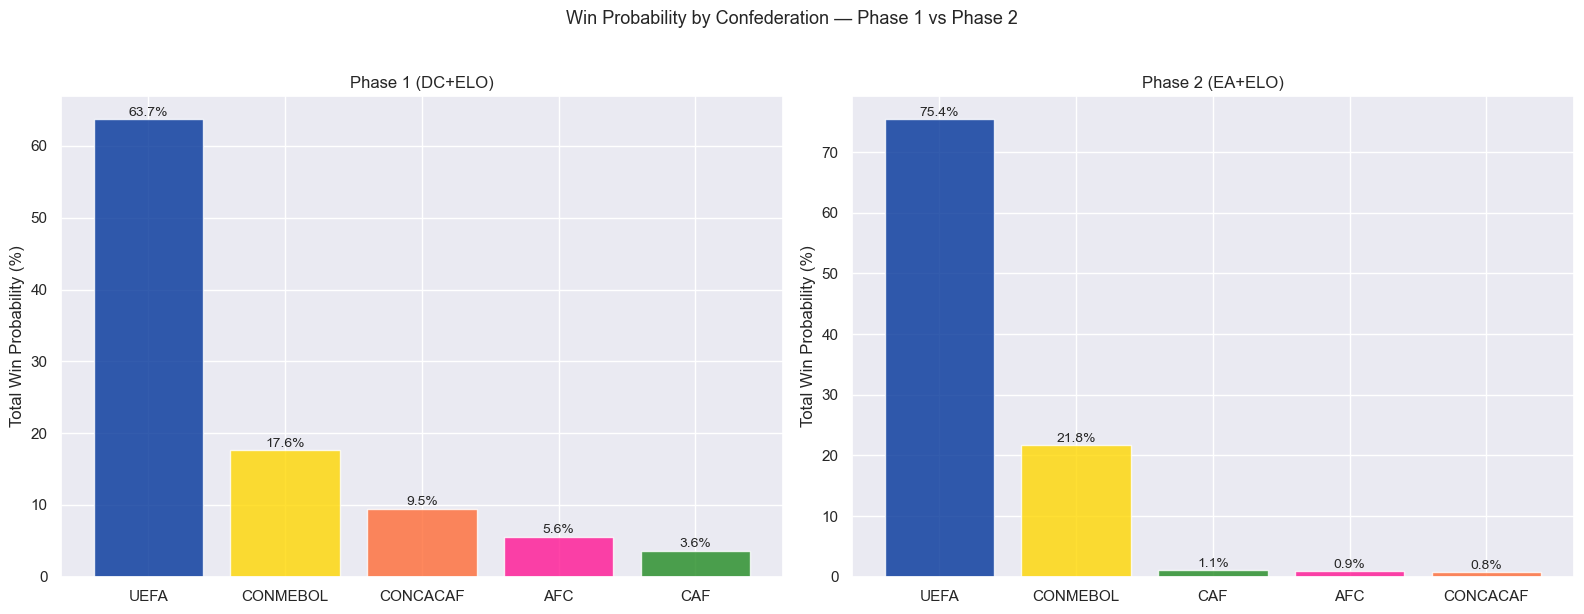

In [14]:
# Confederation breakdown comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

conf_colors = {'UEFA':'#003399','CONMEBOL':'#FFD700','CONCACAF':'#FF6B35',
               'CAF':'#228B22','AFC':'#FF1493','OFC':'#00CED1'}

for ax, col, title in [(axes[0], 'phase1_pct', 'Phase 1 (DC+ELO)'),
                        (axes[1], 'phase2_pct', 'Phase 2 (EA+ELO)')]:
    conf_totals = comparison.groupby('confederation')[col].sum().sort_values(ascending=False)
    bars = ax.bar(conf_totals.index, conf_totals.values,
                  color=[conf_colors.get(c, '#999') for c in conf_totals.index], alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Total Win Probability (%)')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.suptitle('Win Probability by Confederation — Phase 1 vs Phase 2', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../images/phase2_04_conf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

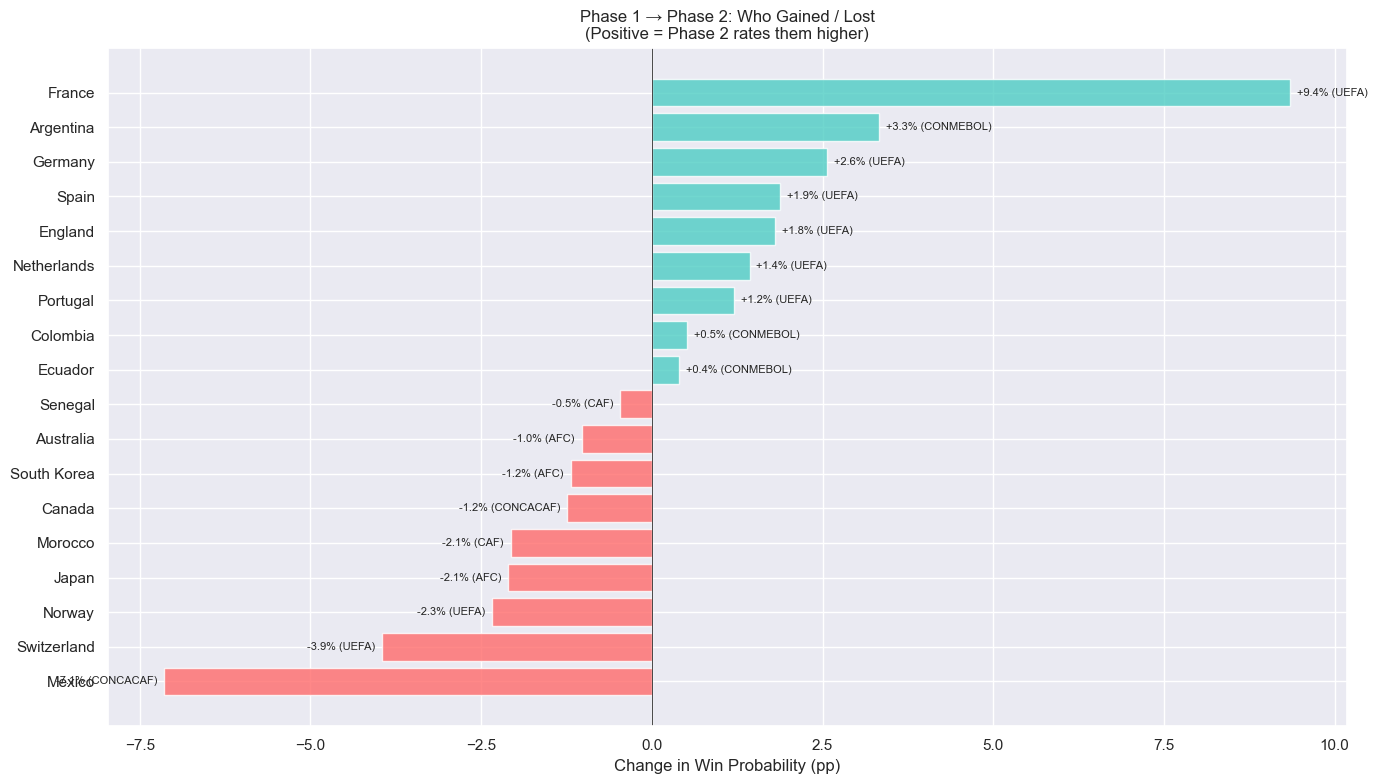

In [15]:
# Delta chart — who gained, who lost
fig, ax = plt.subplots(figsize=(14, 8))

movers = comparison[comparison['delta'].abs() > 0.3].sort_values('delta')
colors = ['#FF6B6B' if d < 0 else '#4ECDC4' for d in movers['delta']]
ax.barh(movers['team'], movers['delta'], color=colors, alpha=0.8)
ax.set_xlabel('Change in Win Probability (pp)')
ax.set_title('Phase 1 → Phase 2: Who Gained / Lost\n(Positive = Phase 2 rates them higher)', fontsize=12)
ax.axvline(0, color='black', linewidth=0.5)

for i, (_, r) in enumerate(movers.iterrows()):
    conf = r['confederation']
    ax.text(r['delta'] + (0.1 if r['delta'] >= 0 else -0.1), i,
            f"{r['delta']:+.1f}% ({conf})", va='center', fontsize=8,
            ha='left' if r['delta'] >= 0 else 'right')

plt.tight_layout()
plt.savefig('../images/phase2_04_delta.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Save Phase 2 results
win_probs_full = win_probs.copy()
win_probs_full['confederation'] = win_probs_full['team'].map(confs).fillna('UNKNOWN')
win_probs_full['elo'] = win_probs_full['team'].map(elos).round(1)
win_probs_full = win_probs_full.merge(teams_2026[['team','group']], on='team', how='left')

win_probs_full.to_csv(PROCESSED_DIR / 'wc2026_simulation_results_phase2.csv', index=False)
round_df.to_csv(PROCESSED_DIR / 'wc2026_round_analysis_phase2.csv', index=False)

print('Saved:')
print('  wc2026_simulation_results_phase2.csv')
print('  wc2026_round_analysis_phase2.csv')
print()
print(f'Phase 2 model: XGB×{W_XGB} + RF×{W_RF}, {len(FEATURE_COLS)} features, ll={bundle["log_loss"]:.4f}')
print(f'Scorelines: Reverse Poisson (no Dixon-Coles)')
print(f'Simulations: {N_SIMS:,}')

Saved:
  wc2026_simulation_results_phase2.csv
  wc2026_round_analysis_phase2.csv

Phase 2 model: XGB×3 + RF×1, 97 features, ll=0.8258
Scorelines: Reverse Poisson (no Dixon-Coles)
Simulations: 10,000
